In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../regression/salary_data_regression.csv")
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [3]:
df_cleaned = df.dropna()
df_cleaned = df_cleaned.drop_duplicates()
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

df_cleaned['YearsExperience'] = pd.to_numeric(df_cleaned['Years of Experience'], errors='coerce')
df_cleaned['Salary'] = pd.to_numeric(df_cleaned['Salary'], errors='coerce')

Original shape: (375, 6)
Cleaned shape: (324, 6)


In [4]:
df_cleaned = df_cleaned[(df_cleaned['Salary'] < df_cleaned['Salary'].quantile(0.95))]

In [5]:
# Basic info
print(df_cleaned.info())
print(df_cleaned.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 371
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  297 non-null    float64
 1   Gender               297 non-null    object 
 2   Education Level      297 non-null    object 
 3   Job Title            297 non-null    object 
 4   Years of Experience  297 non-null    float64
 5   Salary               297 non-null    float64
 6   YearsExperience      297 non-null    float64
dtypes: float64(4), object(3)
memory usage: 18.6+ KB
None
              Age  Years of Experience         Salary  YearsExperience
count  297.000000           297.000000     297.000000       297.000000
mean    36.363636             9.111111   91819.360269         9.111111
std      6.584874             6.080355   41786.702235         6.080355
min     23.000000             0.000000     350.000000         0.000000
25%     31.000000             3.000000

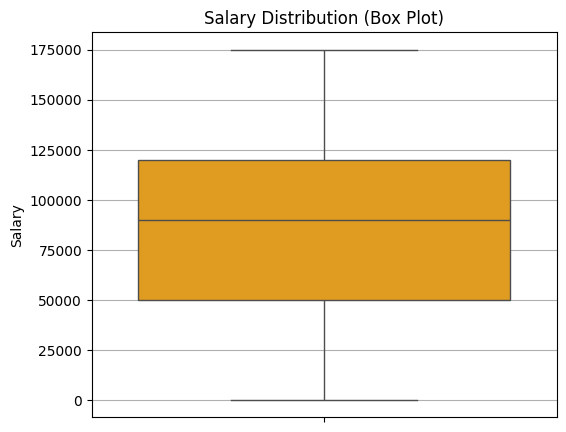

In [6]:
# Box Plot - Salary Distribution
plt.figure(figsize=(6, 5))
sns.boxplot(y='Salary', data=df_cleaned, color='orange')
plt.title('Salary Distribution (Box Plot)')
plt.ylabel('Salary')
plt.grid(True, axis='y')
plt.show()

/var/folders/nw/c745mgyj79lf4r0gkq4qslmr0000gn/T/ipykernel_6961/2118500508.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Salary', data=avg_salary_by_gender, palette='Set2')


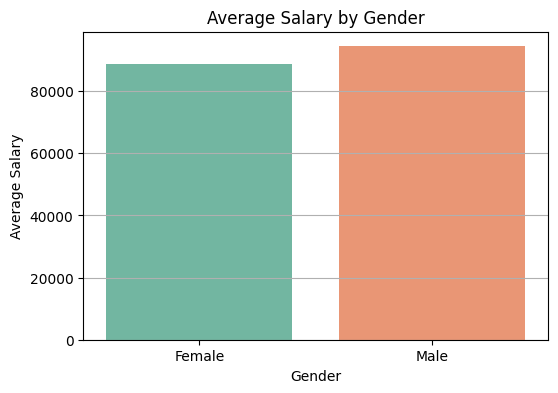

In [7]:
# Group by Gender and compute average salary
avg_salary_by_gender = df_cleaned.groupby('Gender')['Salary'].mean().reset_index()

# Bar plot - Average Salary by Gender
plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Salary', data=avg_salary_by_gender, palette='Set2')
plt.title('Average Salary by Gender')
plt.ylabel('Average Salary')
plt.xlabel('Gender')
plt.grid(axis='y')
plt.show()

In [8]:
X = df_cleaned[['Years of Experience']] # Features
y = df_cleaned['Salary'] # Target

X represents your features (inputs), which are the independent variables you're using to make predictions.
y represents your target (output), which is the dependent variable you're trying to predict.

test_size=0.2 specifies that 20% of the data should be used for testing, and the remaining 80% will be used for training the model.

random_state=42 ensures that the split is reproducible. If you use the same random_state value every time, you’ll get the same split each time you run the code. If you omit this parameter or set it to None, you'll get a different split each time.

X_train and y_train are the features and target values for the training set.
X_test and y_test are the features and target values for the test set.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# Then, make predictions
y_pred = model.predict(X_test)

In [10]:
rounded_predictions = np.round(y_pred, 2)
print(rounded_predictions)

[ 46802.64  43647.34 103598.07  59423.85 109908.67 166704.1  135151.08
  43647.34  53113.25 147772.29 128840.48  72045.06  65734.45  72045.06
 103598.07 154082.89  46802.64 122529.88  90976.86  53113.25  53113.25
  78355.66  84666.26 109908.67 109908.67 135151.08  53113.25 128840.48
  34181.44 135151.08 135151.08 147772.29  40492.04 191946.51  40492.04
  46802.64 141461.69 109908.67  84666.26  46802.64  84666.26 122529.88
  84666.26  65734.45 122529.88  90976.86  46802.64  78355.66  78355.66
  59423.85 116219.27 135151.08  53113.25 128840.48 128840.48  40492.04
 128840.48  84666.26  59423.85  90976.86]


In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error: 341617906.60
R-squared (R²): 0.81


In [12]:
# Ensure y_pred is rounded to two decimal places
y_pred_rounded = np.round(y_pred, 2)

# Create a DataFrame to compare actual vs predicted
comparison_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred_rounded
})

print(comparison_df)

    Actual Salary  Predicted Salary
0         40000.0          46802.64
1         50000.0          43647.34
2         70000.0         103598.07
3         50000.0          59423.85
4        120000.0         109908.67
5        135000.0         166704.10
6        130000.0         135151.08
7         45000.0          43647.34
8         75000.0          53113.25
9        140000.0         147772.29
10       150000.0         128840.48
11        55000.0          72045.06
12        50000.0          65734.45
13        90000.0          72045.06
14       120000.0         103598.07
15       150000.0         154082.89
16        40000.0          46802.64
17       115000.0         122529.88
18       120000.0          90976.86
19        45000.0          53113.25
20        50000.0          53113.25
21        85000.0          78355.66
22        90000.0          84666.26
23        60000.0         109908.67
24       130000.0         109908.67
25       150000.0         135151.08
26        45000.0          5

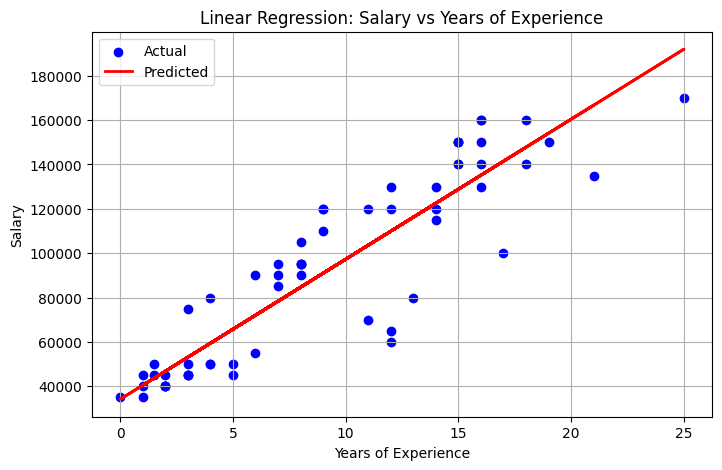

In [13]:
# Linear Regression
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.title('Linear Regression: Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

The model shows good predictive power, explaining about 81% of the variation in salaries. However, with an average error of around $18,000, its predictions can still be off by a noticeable amount. 

Based on the model's evaluation metrics — particularly an R-squared (R²) value of around 0.81, we can conclude that the regression model explains approximately 81% of the variance in salary using the available features (like years of experience, job title, education, and gender). This indicates a strong relationship between the predictors and the salary, meaning the model is relatively good at capturing salary trends from the data.

However, the Root Mean Squared Error (RMSE) of around $18,000 suggests that predictions can still be off by a substantial margin, especially for lower-salary roles. This level of error may be acceptable in some business contexts (e.g., strategic planning), but too imprecise for others (e.g., individual salary offers). The model’s performance could be improved by using a larger dataset and incorporating more influential features such as industry, company size, and location. Nonetheless, as a starting point, this model demonstrates useful predictive power.